# Driven Two-Level Systems & Dissipative Steady States

This notebook simulates a two-level system (qubit) under continuous **Rabi drive** and **amplitude damping**, finding both numerical steady-state solutions and comparing them with **analytical closed-form** Bloch equations.

## 1. Physics and Analytical Theory

Consider a qubit driven by a classical electromagnetic field with drive strength (Rabi frequency) $\Omega$ and detuning $\Delta$ from resonance. The Hamiltonian in the rotating frame is:

$$H = \frac{\Omega}{2} \sigma_x + \frac{\Delta}{2} \sigma_z$$

Subject to amplitude damping (energy relaxation) with collapse operator $L = \sigma_-$ and decay rate $\gamma$.

### Steady-State Bloch Vector Components
Writing the Lindblad master equation in terms of the Bloch vector components $x = \langle\sigma_x\rangle$, $y = \langle\sigma_y\rangle$, $z = \langle\sigma_z\rangle$ yields the Bloch equations:

$$\frac{dx}{dt} = -\Delta y - \frac{\gamma}{2} x$$

$$\frac{dy}{dt} = \Delta x - \Omega z - \frac{\gamma}{2} y$$

$$\frac{dz}{dt} = \Omega y + \gamma(1 - z)$$

By setting the derivatives to zero, we obtain the **analytical steady state** ($t \to \infty$):

$$x_{ss} = \frac{4\Omega\Delta}{\gamma^2 + 2\Omega^2 + 4\Delta^2}$$

$$y_{ss} = -\frac{2\Omega\gamma}{\gamma^2 + 2\Omega^2 + 4\Delta^2}$$

$$z_{ss} = \frac{\gamma^2 + 4\Delta^2}{\gamma^2 + 2\Omega^2 + 4\Delta^2}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

def pauli_matrices():
    return (
        np.array([[0, 1], [1, 0]], dtype=complex),
        np.array([[0, -1j], [1j, 0]], dtype=complex),
        np.array([[1, 0], [0, -1]], dtype=complex)
    )

def spin_operators():
    return (
        np.array([[0, 1], [0, 0]], dtype=complex), # sm = |g><e|
        np.array([[0, 0], [1, 0]], dtype=complex)  # sp = |e><g|
    )

def bloch_vector(rho):
    sx, sy, sz = pauli_matrices()
    return np.array([
        np.trace(rho @ sx).real,
        np.trace(rho @ sy).real,
        np.trace(rho @ sz).real
    ])

def lindblad_superoperator(H, L_list, gamma_list):
    n = H.shape[0]
    I = np.eye(n)
    L = -1j * (np.kron(I, H) - np.kron(H.T, I))
    for Lk, gk in zip(L_list, gamma_list):
        term1 = np.kron(Lk.conj(), Lk)
        Lk_dag_Lk = Lk.conj().T @ Lk
        term2 = -0.5 * np.kron(I, Lk_dag_Lk)
        term3 = -0.5 * np.kron(Lk_dag_Lk.T, I)
        L += gk * (term1 + term2 + term3)
    return L

def lindblad_solve(H, rho0, tlist, L_list, gamma_list):
    n = H.shape[0]
    L_op = lindblad_superoperator(H, L_list, gamma_list)
    rho0_vec = rho0.reshape(-1, order='F')
    rhos = []
    for t in tlist:
        rho_t_vec = expm(L_op * t) @ rho0_vec
        rhos.append(rho_t_vec.reshape(n, n, order='F'))
    return np.array(rhos)

## 2. SVD-Based Numerical Steady-State Solver

The steady-state density matrix satisfies $\mathcal{L} |\rho_{ss}\rangle\!\rangle = 0$. That is, $|\rho_{ss}\rangle\!\rangle$ is in the null space of the Liouvillian superoperator $\mathcal{L}$. We compute this numerically by performing Singular Value Decomposition (SVD):

$$\mathcal{L} = U S V^\dagger$$

The right-singular vector corresponding to the singular value zero (the last column of $V$, or last row of $V^\dagger$) gives $|\rho_{ss}\rangle\!\rangle$.

In [ ]:
def steady_state(H, L_list=None, gamma_list=None):
    """Find the steady-state density matrix using SVD of the Liouvillian superoperator."""
    L_op = lindblad_superoperator(H, L_list, gamma_list)
    n = H.shape[0]

    # Perform SVD
    u, s, vh = np.linalg.svd(L_op)
    
    # The last row of vh corresponds to the smallest singular value (zero)
    rho_ss_vec = vh[-1, :].conj()

    # Reshape and normalize
    rho_ss = rho_ss_vec.reshape(n, n, order='F')
    rho_ss = rho_ss / np.trace(rho_ss)
    
    # Enforce hermiticity
    rho_ss = (rho_ss + rho_ss.conj().T) / 2
    return rho_ss

def analytical_steady_state_driven(Omega, gamma, Delta=0.0):
    """Compute analytical steady state density matrix."""
    sx, sy, sz = pauli_matrices()
    denom = gamma**2 + 2 * Omega**2 + 4 * Delta**2
    x_ss = 4 * Omega * Delta / denom
    y_ss = -2 * Omega * gamma / denom
    z_ss = (gamma**2 + 4 * Delta**2) / denom
    
    # Bloch vector components map to density matrix
    rho_ss = 0.5 * (np.eye(2) + x_ss * sx + y_ss * sy + z_ss * sz)
    return rho_ss

## 3. Simulation of Driven Qubit Time Evolution

We simulate the time evolution under a resonant Rabi drive $\Omega = 2.0$ with decay rate $\gamma = 1.0$, starting from $|0\rangle$.

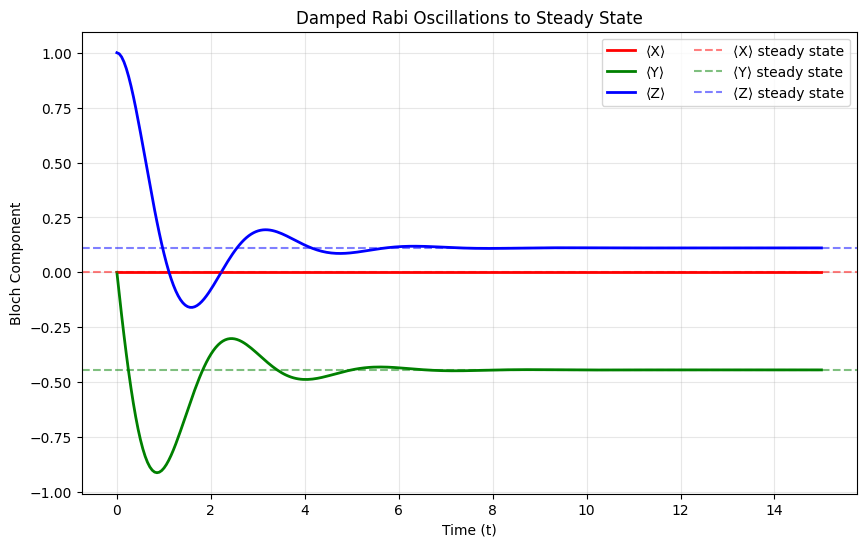

In [ ]:
Omega = 2.0
gamma = 1.0
tlist = np.linspace(0, 15, 300)
rho0 = np.array([[1, 0], [0, 0]], dtype=complex)

sx, sy, sz = pauli_matrices()
sm, _ = spin_operators()

# Resonant Hamiltonian: Delta = 0
H = 0.5 * Omega * sx

# Run solver
rhos = lindblad_solve(H, rho0, tlist, [sm], [gamma])
bvs = np.array([bloch_vector(r) for r in rhos])

# Steady state analytical
r_ss = bloch_vector(analytical_steady_state_driven(Omega, gamma))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(tlist, bvs[:, 0], 'r-', label='⟨X⟩', lw=2)
plt.plot(tlist, bvs[:, 1], 'g-', label='⟨Y⟩', lw=2)
plt.plot(tlist, bvs[:, 2], 'b-', label='⟨Z⟩', lw=2)
plt.axhline(y=r_ss[0], color='r', linestyle='--', alpha=0.5, label='⟨X⟩ steady state')
plt.axhline(y=r_ss[1], color='g', linestyle='--', alpha=0.5, label='⟨Y⟩ steady state')
plt.axhline(y=r_ss[2], color='b', linestyle='--', alpha=0.5, label='⟨Z⟩ steady state')
plt.xlabel('Time (t)')
plt.ylabel('Bloch Component')
plt.title('Damped Rabi Oscillations to Steady State')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

## 4. High-Precision Sweep and Validation

We sweep the drive strength $\Omega$ from $0$ to $10$ and compare the SVD-based numerical steady state with the closed-form analytical formulas, asserting machine-precision matching.

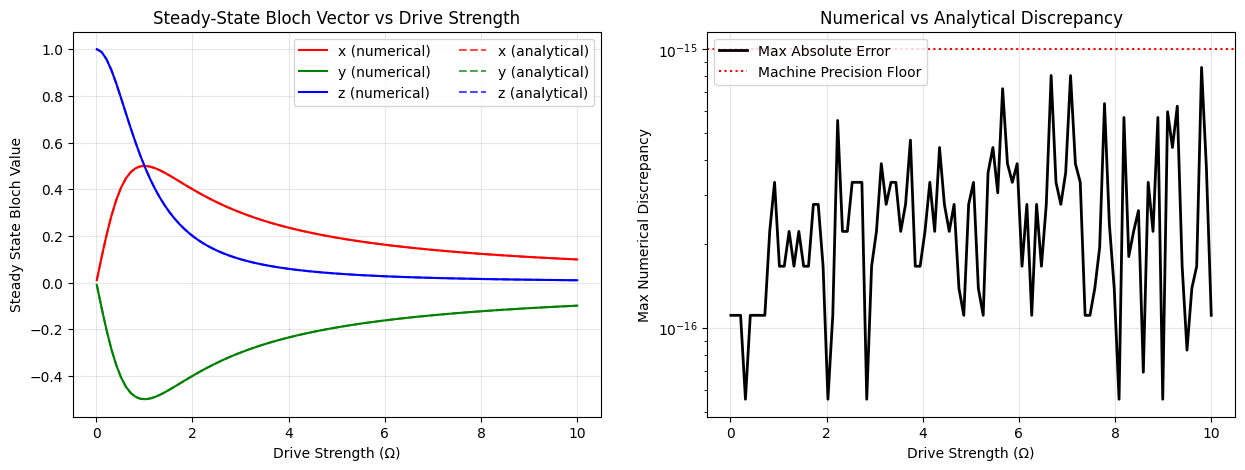

Maximum difference across the entire sweep: 8.60e-16


In [ ]:
Omega_range = np.linspace(0.01, 10, 100)
Delta = 0.5 # Add small detuning to test all elements

numerical_bvs = []
analytical_bvs = []

for Omg in Omega_range:
    # Numerical SVD solver
    H_num = 0.5 * Omg * sx + 0.5 * Delta * sz
    rho_ss_num = steady_state(H_num, [sm], [gamma])
    numerical_bvs.append(bloch_vector(rho_ss_num))

    # Analytical equations
    rho_ss_ana = analytical_steady_state_driven(Omg, gamma, Delta)
    analytical_bvs.append(bloch_vector(rho_ss_ana))

numerical_bvs = np.array(numerical_bvs)
analytical_bvs = np.array(analytical_bvs)

# Compute differences
diffs = np.max(np.abs(numerical_bvs - analytical_bvs), axis=1)

# Plot Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(Omega_range, numerical_bvs[:, 0], 'r-', label='x (numerical)')
ax1.plot(Omega_range, numerical_bvs[:, 1], 'g-', label='y (numerical)')
ax1.plot(Omega_range, numerical_bvs[:, 2], 'b-', label='z (numerical)')
ax1.plot(Omega_range, analytical_bvs[:, 0], 'r--', alpha=0.7, label='x (analytical)')
ax1.plot(Omega_range, analytical_bvs[:, 1], 'g--', alpha=0.7, label='y (analytical)')
ax1.plot(Omega_range, analytical_bvs[:, 2], 'b--', alpha=0.7, label='z (analytical)')
ax1.set_xlabel('Drive Strength (Ω)')
ax1.set_ylabel('Steady State Bloch Value')
ax1.set_title('Steady-State Bloch Vector vs Drive Strength')
ax1.legend(ncol=2)
ax1.grid(True, alpha=0.3)

ax2.semilogy(Omega_range, diffs, 'k-', lw=2, label='Max Absolute Error')
ax2.axhline(y=1e-15, color='r', linestyle=':', label='Machine Precision Floor')
ax2.set_xlabel('Drive Strength (Ω)')
ax2.set_ylabel('Max Numerical Discrepancy')
ax2.set_title('Numerical vs Analytical Discrepancy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.show()

print(f"Maximum difference across the entire sweep: {np.max(diffs):.2e}")
assert np.max(diffs) < 1e-12